In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import numpy as np
import scipy
import copy

from scipy.sparse import coo_matrix, block_diag, identity, hstack, csr_matrix, csc_matrix, vstack
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import time 

from pyiga import assemble, bspline, vform, geometry, vis, solvers, utils, topology, ieti, algebra, operators, adaptive
from pyiga import algebra_cy, ieti_cy, bspline_cy

from scipy.sparse.linalg import aslinearoperator as LinOp

np.set_printoptions(linewidth=100000)
np.set_printoptions(precision=5)

In [7]:
from importlib.metadata import distributions

for d in distributions():
    if "pardiso" in d.metadata["Name"].lower():
        print(d.metadata["Name"], d.version)

pypardiso 0.4.7
py-mkl-pardiso 0.0.5


In [2]:
def admissibility_split(MP, a, return_P=False, subspace=False, consistency = True, with_edges=False):
    level={1:5, 2:5, 3:5, 4:5, 5:5, 6:5, 7:5}
    marked = set()
    mapped = lambda x: 1 if x in (0, 1) else 0
    num_split=0
    assert isinstance(a,dict) and len(a)==len(MP.mesh.domains), 'Invalid type for diffusion coefficient'
    if return_P:
        P = scipy.sparse.identity(MP.nLocDofs)
    while True:
        for p in range(MP.mesh.numpatches):
            for b in range(4):
                kv = MP.mesh.kvs[p][mapped(b)]
                deg = kv.p
                s1,s2 = kv.support()
                nodes = np.clip(MP.mesh.boundaries(p)[1][b],kv.kv[0],kv.kv[-1])
                m = min(nodes[1:]-nodes[:-1])
                if not bspline_cy.pyx_checkSWcondition(kv.kv, kv.p, len(kv.kv), nodes, len(nodes), with_edges) or (s2-s1)/m>2**level[deg]-1:
                    marked.add(p)
        if consistency:
            for (p1,b1) in MP.mesh.L_intfs:
                if len(MP.mesh.L_intfs[(p1,b1)])>1:
                    p2 = MP.mesh.L_intfs[(p1,b1)][0][0]
                    if a[MP.mesh.patch_domains[p1]] + 1e-3 < a[MP.mesh.patch_domains[p2]]:
                        marked.add(p1)
        if len(marked)>0:
            num_split+=len(marked)
            if return_P:
                P = MP.h_refine({p:None for p in marked}, ref="rs", return_P=return_P, in_subspace=subspace) @ P
            else:
                MP.h_refine({p:None for p in marked}, ref="rs", return_P=return_P, in_subspace=subspace)
            marked=set()
        else:
            break
    if consistency:
        print("Split {} additional patches due to admissibility and consistency".format(num_split))
    else:
        print("Split {} additional patches due to admissibility".format(num_split))
    if return_P:
        return P

In [51]:
def Inductor(deg,N, airgap=0.025, thin=False):
    kvs=42*[2*(bspline.make_knots(deg,0.0,1.0,N),)]
    
    geos=[      
        geometry.unit_square().scale((0.5)).translate((-0.5,-0.5)),
        geometry.unit_square().scale((0.25,0.5)).translate((0,-0.5)),
        geometry.unit_square().scale((0.25,0.5)).translate((0.25,-0.5)),
        geometry.unit_square().scale((0.5,0.5)).translate((0.5,-0.5)),
        geometry.unit_square().scale((0.25,0.5)).translate((1.,-0.5)),
        geometry.unit_square().scale((0.25,0.5)).translate((1.25,-0.5)),
        geometry.unit_square().scale(0.5).translate((1.5,-0.5)),
        
        geometry.unit_square().scale((0.5,0.25)).translate((-0.5,0)),
        geometry.unit_square().scale(0.25),
        geometry.unit_square().scale(0.25).translate((0.25,0)),
        geometry.unit_square().scale((0.5,0.25)).translate((0.5,0)),
        geometry.unit_square().scale((0.25,0.25)).translate((1.,0)),
        geometry.unit_square().scale((0.25,0.25)).translate((1.25,0)),
        geometry.unit_square().scale((0.5,0.25)).translate((1.5,0)),
        
        geometry.unit_square().scale((0.5,airgap)).translate((-0.5,0.25)),
        geometry.unit_square().scale((0.25,airgap)).translate((0,0.25)),
        geometry.unit_square().scale((0.25,airgap)).translate((0.25,0.25)),
        geometry.unit_square().scale((0.5,airgap)).translate((0.5,0.25)),
        geometry.unit_square().scale((0.25,airgap)).translate((1.,0.25)),
        geometry.unit_square().scale((0.25,airgap)).translate((1.25,0.25)),
        geometry.unit_square().scale((0.5,airgap)).translate((1.5,0.25)),
        
        geometry.unit_square().scale((0.5,0.5)).translate((-0.5,0.25+airgap)),
        geometry.unit_square().scale((0.25,0.5)).translate((0,0.25+airgap)),
        geometry.unit_square().scale((0.25,0.5)).translate((0.25,0.25+airgap)),
        geometry.unit_square().scale((0.5,0.5)).translate((0.5,0.25+airgap)),
        geometry.unit_square().scale((0.25,0.5)).translate((1.,0.25+airgap)),
        geometry.unit_square().scale((0.25,0.5)).translate((1.25,0.25+airgap)),
        geometry.unit_square().scale((0.5,0.5)).translate((1.5,0.25+airgap)),
        
        geometry.unit_square().scale((0.5,0.25)).translate((-0.5,0.75+airgap)),
        geometry.unit_square().scale((0.25,0.25)).translate((0,0.75+airgap)),
        geometry.unit_square().scale((0.25,0.25)).translate((0.25,0.75+airgap)),
        geometry.unit_square().scale((0.5,0.25)).translate((0.5,0.75+airgap)),
        geometry.unit_square().scale((0.25,0.25)).translate((1.,0.75+airgap)),
        geometry.unit_square().scale((0.25,0.25)).translate((1.25,0.75+airgap)),
        geometry.unit_square().scale((0.5,0.25)).translate((1.5,0.75+airgap)),
        
        geometry.unit_square().scale(0.5).translate((-0.5,1.0+airgap)),
        geometry.unit_square().scale((0.25,0.5)).translate((0,1.0+airgap)),
        geometry.unit_square().scale((0.25,0.5)).translate((0.25,1.0+airgap)),
        geometry.unit_square().scale((0.5,0.5)).translate((0.5,1.0+airgap)),
        geometry.unit_square().scale((0.25,0.5)).translate((1.,1.0+airgap)),
        geometry.unit_square().scale((0.25,0.5)).translate((1.25,1.0+airgap)),
        geometry.unit_square().scale(0.5).translate((1.5,1.0+airgap)),
         ]
    patches=list(zip(kvs,geos))
    M = topology.MultiPatch(patches)
    M.rename_domain(0,'Air')
    M.set_domain_id({'Fe':{8,9,10,11,12,22,24,26,29,30,31,32,33}, 'C1':{23}, 'C2':{25}})
    if not thin:
        M.h_refine({i:1 for i in range(14,21)});                                        #split airgap patches further in y-axis to make up for anisotropy 
        M.h_refine({i:1 for i in list(range(14,21))+list(range(42,49))});               #split airgap patches further in y-axis to make up for anisotropy 
    #M.h_refine({i:1 for i in list(range(14,21))+list(range(42,49))+list(range(49,63))}); #split airgap patches further in y-axis to make up for anisotropy
    return M

In [52]:
mu0 = 4.344*np.pi*1e-7
nu = {'C1': 1/mu0, 'C2':1/mu0, 'Fe':1/(2500*mu0), 'Air': 1/mu0}
j = {'C1': lambda x,y: 66/(0.125), 'C2':lambda x,y: -66/(0.125), 'Fe':lambda x,y: 0.0, 'Air': lambda x,y: 0.0}
MaT = {'C1': lambda x,y: (0.,0.), 'C2': lambda x,y:(0.,0.), 'Fe':lambda x,y:(0.,0.), 'Air': lambda x,y:(0.,0.)}
dir_data = {0:0}

In [57]:
degs = (2,3,5)
maxpatches =(4000,3500,3000)
level = (2,1,1)
#maxpatches=(1500,)
maxiter=(20,23,25)
#maxiter=(20,23,25)
R = np.zeros((30,5*len(degs)))
max_k=0
consistency = True
Prec='S'
plot=0
prim = {'v':1, 'e':1}
thin=0
eps=1e-7

for i,deg in enumerate(degs):
    eta = 1
    N = 2*deg + 1
    M = Inductor(deg,N,thin=thin)
    
    IMap = ieti.IetiMapper(M, dir_data)
    admissibility_split(IMap, return_P = False, subspace=False, consistency=consistency, a=nu, with_edges = prim['e']);
    #IMap.mesh.plotmesh();

    print("======================================================")
    print("deg = "+str(deg))
    k=0
    while k < maxiter[i]:
        print(k)
        print("Number of patches: {}".format(IMap.nPatches))
        if plot:
            M.plotmesh(figsize=(8,8),color={'C1':'yellow', 'C2':'yellow', 'Fe':'darkgrey', 'Air':'white'}, knots=0, bwidth=0.01, patch_idx=0)
            plt.axis('off');
            plt.axis('scaled');
            #plt.savefig('/home/wolfman/Pictures/Inductor/p'+str(deg)+'/i'+str(k)+'.pdf',bbox_inches='tight');
            #plt.close();
            plt.show()
        
        ### Solve
        IMap.parametersort(nu)
        A, RHS = IMap.assemble(a=nu,f=j, M=None)
        N = [A.shape[0] for A in A]

        Prim = csc_matrix((IMap.N_ofs_elim[-1],0))

        if bool(prim['v']):
            PrimV, to_be_eliminated = IMap.nodes_as_primals(dir_boundary=False)
            Prim = scipy.sparse.hstack([Prim, PrimV])
        if bool(prim['e']):
            Prim = scipy.sparse.hstack([Prim, IMap.interface_averages_as_primals(level[i])])

        print(Prim.shape)
        B, eliminated_constraints = IMap.ConstraintMatrices(eliminate=to_be_eliminated)
        SD = ieti.ScaledDirichletPreconditioner(A, B, IMap)

        nPrim=Prim.shape[1]

        R[k,i*5+3]=nPrim
        R[k,i*5+4]=IMap.nPatches

        primal = ieti.PrimalSystem(Prim)
        modA, modB, modRHS, C = primal.incorporate_PrimalConstraints(A, B, RHS, IMap)
    
        loc_solver = primal.compute_PrimalBasis(modA, modB, modRHS, C)
            
        modA.append(primal.A_prim), modB.append(primal.B_prim), modRHS.append(primal.RHS_prim)
        loc_solver.append(solvers.make_solver(primal.A_prim, spd=True, symm=True)), N.append(primal.A_prim.shape[0])
            
        I = ieti.IetiSystem(modA, modB, modRHS, N, loc_solver)
        F, b = I.SchurComplement(), I.RHSforSchurComplement()

        if Prec=='S':
            SD.setupSelectionScaling()
            P = SD.AsOperator()
        elif Prec=='D':
            SD.SchurAsMatrices()
            P=ieti.EdgePreconditioner(IMap, SD.S_dense, SD.B ,C)
        else:
            print('error')
        
        lam, it, min_eig, max_eig, r = solvers.pcg(F, b, x0=None, maxiter=2000, P=P, output=1, rtol=1e-8, atol=1e-12)
        R[k,i*5+1] = it
        R[k,i*5+2] = max_eig/min_eig

        uh = I.constructSolutionFromLagrangeMultipliers(lam)
        uh = primal.distributePrimalSolution(uh)
        uh = np.concatenate(IMap.completeDirichlet(uh))
            
        err_ind=adaptive.mp_resPois(IMap, uh, nu=nu, f=j)
        eta = np.linalg.norm(err_ind)
        #eta.append(eta)
        R[k,i*5] = eta
        #print(eta[-1]/Eerr)

        print("Error Estimator: {:.3}".format(eta))
        marked_patches = adaptive.doerfler_mark(err_ind, theta=0.8, TOL=0.01)
        marked_patches = {p:None for p in marked_patches}

        if IMap.nPatches + 3*len(marked_patches) >= maxpatches[i]:
            break;

        if eta < eps:
            break;

        P = IMap.h_refine(h_ref=marked_patches,ref="rs", return_P = False, in_subspace=False)

        admissibility_split(IMap, return_P = False, subspace=False, consistency=consistency, a=nu, with_edges =  prim['e']);

        k+=1
        print("#####################################################")

    max_k=max(k,max_k)

R=R[:max_k,:]
if prim['e']:
    if thin:
        if consistency:
            np.save("Inductor_"+Prec+"_B_consistency_thin",R)
        else:
            np.save("Inductor_"+Prec+"_B_thin",R)
    else:
        if consistency:
            np.save("Inductor_"+Prec+"_B_consistency",R)
        else:
            np.save("Inductor_"+Prec+"_B",R)
else:
    if thin:
        if consistency:
            np.save("Inductor_"+Prec+"_A_consistency_thin",R)
        else:
            np.save("Inductor_"+Prec+"_A_thin",R)
    else:
        if consistency:
            np.save("Inductor_"+Prec+"_A_consistency",R)
        else:
            np.save("Inductor_"+Prec+"_A",R)

setting up constraints took 0.09392952919006348 seconds.
setting up constraints took 0.16686081886291504 seconds.
setting up constraints took 0.23802924156188965 seconds.
Split 32 additional patches due to admissibility and consistency
deg = 2
0
Number of patches: 159
(7791, 502)
pcg with preconditioned condition number κ ~ 3.274 stopped after 15 iterations with relres 4.991e-09 after 0.105 seconds.
Error Estimator: 1.37
setting up constraints took 0.3163325786590576 seconds.
setting up constraints took 0.3385791778564453 seconds.
Split 4 additional patches due to admissibility and consistency
#####################################################
1
Number of patches: 219
(10731, 718)
pcg with preconditioned condition number κ ~ 3.737 stopped after 16 iterations with relres 4.392e-09 after 0.167 seconds.
Error Estimator: 0.883
setting up constraints took 0.41880178451538086 seconds.
Split 0 additional patches due to admissibility and consistency
#########################################

KeyboardInterrupt: 

In [21]:
RS = np.load('Inductor_S_B_consistency_thin.npy')
RD = np.load('Inductor_D_B_consistency_thin.npy')

In [13]:
SA.shape

(24, 15)

In [15]:
degs=(2,3,5)

In [16]:
R = np.zeros((25,16))
R[:,0]=np.arange(25)
R[:,np.array([1,2,3,6,7,8,11,12,13])]=RS[:,np.array([0,1,2,5,6,7,10,11,12])]
R[:,np.array([4,5,9,10,14,15])]=RD[:,np.array([1,2,6,7,11,12])]
np.savetxt('Inductor_B', R, fmt=('%d',)+len(degs)*('%1.1e','%d','%1.1f','%d','%1.1f'), delimiter = ' & ', newline='\\\\\n')

In [8]:
i=0
SA[:,i]-SB[:,i]

array([1.19645e-07, 1.72355e-02, 2.49780e-02, 5.33019e-03, 5.14499e-02, 5.39440e-02, 1.43277e-01, 1.17559e-01, 8.02218e-02, 7.62627e-02, 7.88606e-02, 4.79148e-02, 4.14447e-02, 5.30630e-02, 2.17228e-02, 3.13986e-02, 2.22120e-02, 1.86762e-02, 2.00691e-02, 1.11321e-02, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00])

In [5]:
N=2
M = topology.MultiPatch([(2*(bspline.make_knots(deg,0,1,N),),geometry.unit_square())])

NameError: name 'deg' is not defined

In [26]:
deg=2
M = Inductor(deg,2*deg+1,thin=0,airgap=0.2)
mu0 = 4.344*np.pi*1e-7
nu = {'C1': 1/mu0, 'C2':1/mu0, 'Fe':1/(2500*mu0), 'Air': 1/mu0}
j = {'C1': lambda x,y: 66/(0.125), 'C2':lambda x,y: -66/(0.125), 'Fe':lambda x,y: 0.0, 'Air': lambda x,y: 0.0}

In [8]:
def Kellogg(deg,N):
    M = topology.MultiPatch([(2*(bspline.make_knots(deg,0,1,N),),geometry.unit_square())])
    M.h_refine();
    M.h_refine();
    M.set_domain_id({1:{3,6,8,10}})
    return M

In [39]:
M = Kellogg(1,2)
#nu={0:1e2,1:1.0}
j = {0:0.0,1:500.0}

In [41]:
E = 1
Prec='S'
IMap = ieti.IetiMapper(M, dir_data={0:0})
#admissibility_split(IMap, return_P = False, subspace=False, consistency=True, a=nu, with_edges = E);
#IMap.parametersort(nu)
A, RHS = IMap.assemble(a=1e7,f=j,M=None)
N = [A.shape[0] for A in A]

setting up constraints took 0.016848087310791016 seconds.


In [42]:
PrimV, to_be_eliminated = IMap.nodes_as_primals(dir_boundary=False)
Prim = PrimV
if E:
    PrimE = IMap.interface_averages_as_primals()
    Prim = scipy.sparse.hstack([Prim,PrimE])
print(Prim.shape)

(144, 33)


In [43]:
B, eliminated_constraints = IMap.ConstraintMatrices(eliminate=to_be_eliminated)
SD = ieti.ScaledDirichletPreconditioner(A, B, IMap)

In [45]:
primal = ieti.PrimalSystem(Prim)
modA, modB, modRHS, C = primal.incorporate_PrimalConstraints(A, B, RHS, IMap)

# for a in modA:
#     print(a.toarray())
    
loc_solver = primal.compute_PrimalBasis(modA, modB, modRHS, C)
            
modA.append(primal.A_prim), modB.append(primal.B_prim), modRHS.append(primal.RHS_prim)
loc_solver.append(solvers.make_solver(primal.A_prim, spd=True, symm=True)), N.append(primal.A_prim.shape[0])
            
I = ieti.IetiSystem(modA, modB, modRHS, N, loc_solver, spd=True)
F, b = I.SchurComplement(), I.RHSforSchurComplement()

In [46]:
if Prec=='S':
    SD.setupSelectionScaling()
    P = SD.AsOperator()
elif Prec=='D':
    SD.SchurAsMatrices()
    P=ieti.EdgePreconditioner(IMap, SD.S_dense, SD.B ,C)
lam, it, min_eig, max_eig, r = solvers.pcg(F, b, x0=None, maxiter=2000, P=1, output=1, rtol=1e-8, atol=1e-12)

pcg with preconditioned condition number κ ~ 1.0 stopped after 0 iterations with relres 1.0 after 0.00058 seconds.


In [47]:
F_full = (F@np.eye(F.shape[0]))
M_full = (P@np.eye(P.shape[0]))

In [48]:
eigs,_=np.linalg.eigh(F_full)
print(eigs.max(),eigs.min())
eigs,_=np.linalg.eigh(M_full)
print(eigs.max(),eigs.min())

3.042570123927291e-23 -4.4141716983341156e-23
18015724.66785709 7400941.998809585


In [49]:
print(np.linalg.norm(F_full - F_full.T))

1.3198613781715012e-23


In [19]:
A = I.A[0]

In [38]:
from pymklpardiso import PardisoSolver
print(A.toarray())
Ah = scipy.sparse.triu(A, format='csr')
solver = PardisoSolver(Ah,mtype=-2)
#solver = PardisoSolver(A,mtype=11)

# solver.set_iparm(7, 2)    # two iterative refinement steps
# solver.set_iparm(10, 1)   # scaling
solver.set_iparm(12, 1)   # weighted matching

solver.factor(Ah.data)
x = np.random.randn(A.shape[1])
y = solver.solve(x)

r = A @ y - x
print(np.linalg.norm(r))

[[ 2.66667e+07 -3.33333e+06 -3.33333e+06 -3.33333e+06  0.00000e+00]
 [-3.33333e+06  1.33333e+07 -3.33333e+06 -1.66667e+06  0.00000e+00]
 [-3.33333e+06 -3.33333e+06  1.33333e+07 -1.66667e+06  0.00000e+00]
 [-3.33333e+06 -1.66667e+06 -1.66667e+06  6.66667e+06  1.00000e+00]
 [ 0.00000e+00  0.00000e+00  0.00000e+00  1.00000e+00  0.00000e+00]]
6.914392812670384e-12


In [85]:
import pymklpardiso
print(pymklpardiso.__version__)

AttributeError: module 'pymklpardiso' has no attribute '__version__'

In [60]:
operators.make_solver(I.A[0],symm=True)

<5x5 SolverWrapper with dtype=float64>

In [73]:
A = I.A[0]
x = np.random.randn(A.shape[0])

A = I.A[p].toarray()
print(np.linalg.cond(A))

for s in [1]:
    As = s * A
    Sp = PardisoSolver(As, mtype=11,msglvl=0)
    y = Sp.solve(x)
    rel = np.linalg.norm(As @ y - x) / np.linalg.norm(x)
    print(s, rel)

1012.2492772503342
11.00000000000001


AttributeError: 'numpy.ndarray' object has no attribute 'indptr'

In [78]:
import importlib.metadata
print(importlib.metadata.version("pymklpardiso"))

PackageNotFoundError: No package metadata was found for pymklpardiso

In [46]:
I.A[0]

<Compressed Sparse Row sparse array of dtype 'float64'
	with 214 stored elements and shape (19, 19)>

In [22]:
A = I.A[0]
S = operators.make_solver(A)

In [23]:
S@A.toarray()

array([[ 1.00000e+00,  0.00000e+00,  0.00000e+00,  9.66063e-17,  5.36442e-17, -2.68221e-17,  0.00000e+00,  9.31751e-19,  2.68221e-17,  6.70552e-18,  5.44824e-18,  9.02385e-19,  9.23298e-17,  0.00000e+00, -1.02516e-17,  5.86853e-19, -3.41059e-17, -2.70989e-15, -2.70989e-15],
       [ 2.19047e-18,  1.00000e+00,  0.00000e+00,  4.75933e-17, -2.41958e-17,  2.68813e-17,  0.00000e+00, -8.48278e-18, -5.19355e-18,  0.00000e+00, -7.54665e-18,  5.17751e-18, -2.40260e-17,  0.00000e+00,  3.03280e-18,  0.00000e+00,  3.03921e-15, -6.72663e-15, -1.67331e-14],
       [-8.17695e-18,  0.00000e+00,  1.00000e+00,  1.15812e-15,  2.68222e-18, -1.43052e-17,  0.00000e+00, -1.43052e-17,  9.72306e-18,  0.00000e+00,  7.15260e-18,  2.86104e-17,  3.80249e-16,  0.00000e+00, -4.63392e-18,  0.00000e+00,  2.89979e-15,  3.87324e-15, -4.07258e-14],
       [-1.63259e-19, -0.00000e+00, -0.00000e+00,  1.00000e+00, -4.24998e-18,  1.15115e-17, -6.85792e-18, -2.50804e-16,  6.30104e-19,  7.65393e-19, -4.82504e-17,  1.25402e-16,

In [713]:
print(np.linalg.matrix_rank(Psi.toarray()))

14


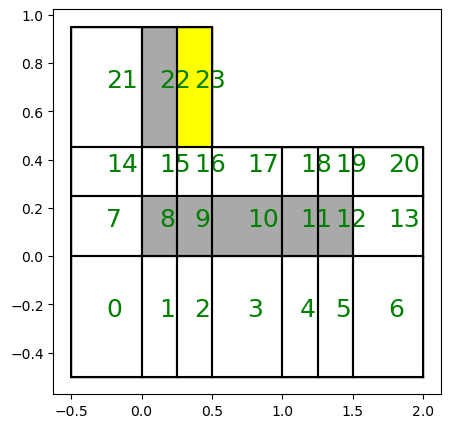

In [249]:
M.plotmesh(color={'C1':'yellow', 'C2':'yellow', 'Fe':'darkgrey', 'Air':'white'}, patch_idx=1)

In [203]:
j['Air'](0.0,0.0)

0.0